In [1]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap, BoundaryNorm

# Set working directory to the project root (parent of Figures/)
# This is idempotent — safe to re-run without moving up extra levels
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())


Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main


In [2]:
# ---------------------------------------------------------------------------
# Data paths (all relative to data/ subdirectory)
# ---------------------------------------------------------------------------

# -------------------------------------------------
# Paths
# -------------------------------------------------
DATA_ROOT = "./data"


districts_path_GEOJSON_PATH = f'{DATA_ROOT}/COMBINED_DIST.geojson'
US_STATES_GEOJSON_PATH = f'{DATA_ROOT}/us_states_for_map.geojson'
COUNTIES_USA_GEOJSON_PATH = f'{DATA_ROOT}/counties_usa_for_map.geojson'
raster_path_LANDCOVER_PATH = f'{DATA_ROOT}/Landcover_for_fig_1.tif'



C:\Users\yaron\AppData\Local\Temp\ipykernel_22776\395214950.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


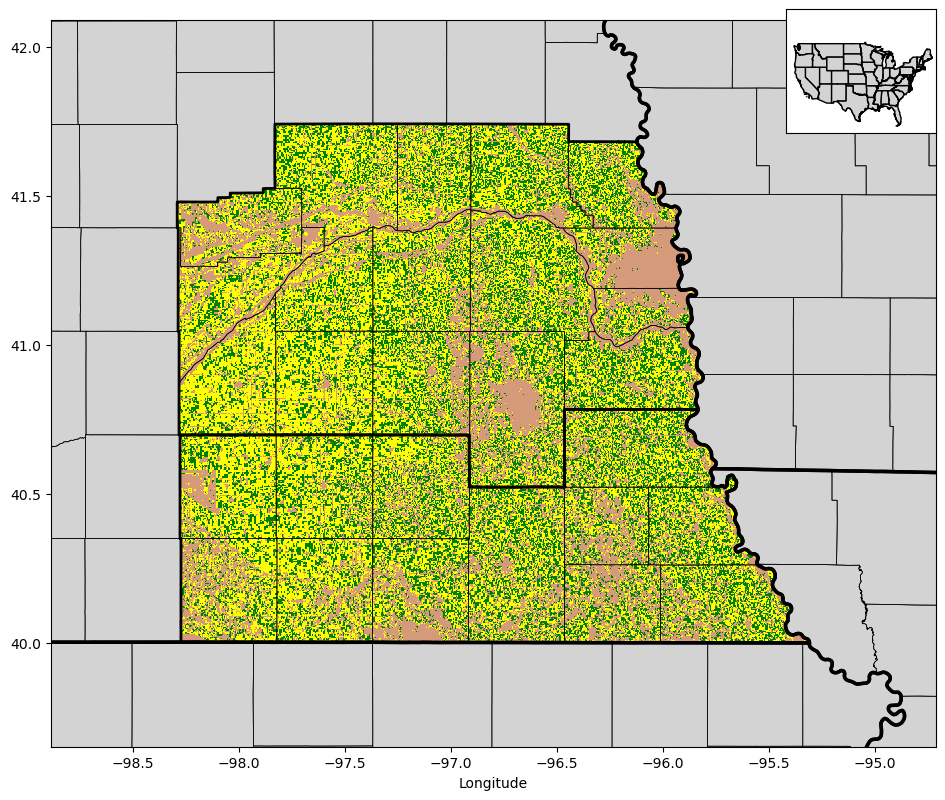

In [3]:


# -------------------------------------------------
# Helper functions
# -------------------------------------------------
def set_zoom(ax, gdf, zoom_factor=0.20):
    x_min, y_min, x_max, y_max = gdf.total_bounds
    x_pad = (x_max - x_min) * zoom_factor
    y_pad = (y_max - y_min) * zoom_factor
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)





def ensure_crs(gdf, target_crs=None):
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    if target_crs is not None:
        gdf = gdf.to_crs(target_crs)
    return gdf


# -------------------------------------------------
# Raster colors
# 0 = hidden / nodata / zero
# 1 = Corn     -> Yellow
# 2 = Soybeans -> Green
# 3 = Other    -> Brown
# -------------------------------------------------
THREE_CLASS_COLORS = {
    1: "#FFFF00",   # Corn
    2: "#008000",   # Soybeans
    3: "#D49A7A",   # Other
}


def classify_cdl_three_classes(arr, nodata_value=None):
    """
    Reclassify CDL raster into:
      masked = nodata or 0  -> not shown
      1 = Corn (CDL == 1)
      2 = Soybeans (CDL == 5)
      3 = Other (all remaining nonzero values)
    """
    classified = np.zeros(arr.shape, dtype=np.uint8)

    # mask no-data / zero
    mask = (arr == 0)
    if nodata_value is not None:
        mask |= (arr == nodata_value)

    # other nonzero classes
    classified[(~mask)] = 3

    # corn and soybeans
    classified[arr == 1] = 1
    classified[arr == 5] = 2

    # make masked array so hidden pixels are not displayed
    classified = np.ma.masked_where(mask, classified)

    return classified


three_class_cmap = ListedColormap([
    THREE_CLASS_COLORS[1],  # class 1 = Corn
    THREE_CLASS_COLORS[2],  # class 2 = Soybeans
    THREE_CLASS_COLORS[3],  # class 3 = Other
])

# make masked pixels transparent
three_class_cmap.set_bad(alpha=0)

three_class_norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], three_class_cmap.N)




# -------------------------------------------------
# Load vector data
# -------------------------------------------------
combined_districts = gpd.read_file(districts_path_GEOJSON_PATH)

us_states = gpd.read_file(US_STATES_GEOJSON_PATH)
counties_usa = gpd.read_file(COUNTIES_USA_GEOJSON_PATH)

# -------------------------------------------------
# CRS handling
# -------------------------------------------------
combined_districts = ensure_crs(combined_districts)
target_crs = combined_districts.crs

us_states = ensure_crs(us_states, target_crs)
counties_usa = ensure_crs(counties_usa, target_crs)




# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax1 = plt.subplots(figsize=(24, 8))

# ----- Raster background with transparent no-data / 0 -----
with rasterio.open(raster_path_LANDCOVER_PATH) as src:
    raster_arr = src.read(1)
    raster_bounds = src.bounds
    raster_nodata = src.nodata

classified_raster = classify_cdl_three_classes(raster_arr, nodata_value=raster_nodata)

ax1.imshow(
    classified_raster,
    cmap=three_class_cmap,
    norm=three_class_norm,
    extent=[raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top],
    origin="upper",
    interpolation="nearest",
    zorder=1
)

# ----- Boundaries and points -----
counties_usa.plot(
    ax=ax1,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    zorder=5
)

combined_districts.plot(
    ax=ax1,
    facecolor="none",
    edgecolor="black",
    linewidth=2.0,
    zorder=15
)

us_states.plot(
    ax=ax1,
    facecolor="none",
    edgecolor="black",
    linewidth=2.5,
    zorder=29
)


# ----- Labels -----
ax1.set_title("", fontsize=14)
ax1.set_facecolor("lightgray")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("")

set_zoom(ax1, combined_districts, zoom_factor=0.20)

# ----- Inset map -----
axins = inset_axes(
    ax1,
    width=1.5,
    height=1.5,
    loc="upper right",
    borderpad=0,
    bbox_to_anchor=(1.00, 1.033),
    bbox_transform=ax1.transAxes
)

x_min, y_min, x_max, y_max = combined_districts.total_bounds
x_pad = (x_max - x_min) * 10
y_pad = (y_max - y_min) * 10

axins.set_xlim(x_min - x_pad, x_max + x_pad)
axins.set_ylim(y_min - y_pad, y_max + y_pad)

us_states.to_crs(epsg=4326).plot(
    ax=axins,
    color="lightgray",
    edgecolor="black",
    alpha=1.0
)


axins.set_xticks([])
axins.set_yticks([])
axins.set_title("")

plt.tight_layout()
plt.show()